<a href="https://colab.research.google.com/github/fluorescentlightpower/mifi_homework/blob/main/%D0%A2%D0%B8%D0%BF%D1%8B_%D1%81%D0%B8%D0%B3%D0%BD%D0%B0%D0%BB%D0%BE%D0%B2_%D1%81%D1%86%D0%B8%D0%BD%D1%82%D0%B8%D0%BB%D0%BB%D1%8F%D1%86%D0%B8%D0%BE%D0%BD%D0%BD%D0%BE%D0%B3%D0%BE_%D0%B4%D0%B5%D1%82%D0%B5%D0%BA%D1%82%D0%BE%D1%80%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Кластеризация сигналов сцинтилляционного детектора

In [189]:
import pandas as pd
import numpy as np
import gdown
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from scipy.optimize import curve_fit
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import hdbscan
from sklearn.decomposition import PCA

Исходный файл загружена на google drive, чтобы не загружать в среду каждый раз

In [ ]:
url = 'https://drive.google.com/uc?id=1SA3DSFkj7CbNYvPcSm5XE5WsnhMtbIG0'
gdown.download(url, 'Run200_Wave_0_1.zip', quiet=False)

dataset = pd.read_csv('Run200_Wave_0_1.zip', sep=' ', header=None, skipinitialspace=True)
dataset = dataset.drop([504], axis=1)
dataset.columns = list(range(504))
dataset.head()


Downloading...
From: https://drive.google.com/uc?id=1SA3DSFkj7CbNYvPcSm5XE5WsnhMtbIG0
To: /content/Run200_Wave_0_1.zip
100%|██████████| 11.7M/11.7M [00:00<00:00, 55.1MB/s]


,0,1,2,3,4,5,6,7,8,9,...,494,495,496,497,498,499,500,501,502,503
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,4928764,740,359,500,14820,14822,14820,14826,14824,14822,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,9630204,162,499,500,14820,14820,14822,14825,14820,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,15798632,841,123,500,14828,14822,14818,14824,14824,14822,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,20637296,412,348,500,14823,14815,14823,14821,14827,14820,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [ ]:
dataset[3].nunique()

1

Попробуем разобраться с первыми четырьмя параметрами. Хоть в прилагаемой работе и говорится, что это всего лишь состояние ФЭУ, есть подозрение, что тут тоже есть полезная информация. Параметр 3 содержит всего лишь одно уникальное значение - 500. Видимо, это длительность регистрации в мс. Удаляем. Параметр 0, видимо, связан с временной меткой регистрации сигнала - не поможет в кластеризации

In [ ]:
dataset.drop(columns=[3], inplace=True)
dataset.head()

,0,1,2,4,5,6,7,8,9,10,...,494,495,496,497,498,499,500,501,502,503
0,2890276,357,113,14820,14823,14824,14822,14818,14820,14824,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,4928764,740,359,14820,14822,14820,14826,14824,14822,14820,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,9630204,162,499,14820,14820,14822,14825,14820,14824,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,15798632,841,123,14828,14822,14818,14824,14824,14822,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,20637296,412,348,14823,14815,14823,14821,14827,14820,14823,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [ ]:
dataset.isna().sum().sum()

np.int64(0)

Пропусков нет. Вычислим площадь под всей кривой сигнала после его вычитания из базовой линии, получается "перевернутый" импульс в более привычной форме, с максимумом. Также определим максимум в пике

In [ ]:
# столбцы сигнала
SIG_START = 3
SIG_END = 503
BASELINE_END = 100

signal_cols = dataset.columns[SIG_START:SIG_END]

# baseline по первым BASELINE_END отсчётам сигнала
dataset["baseline"] = dataset[signal_cols[:BASELINE_END]].mean(axis=1)

# амплитуда импульса
dataset["peak"] = (
    dataset["baseline"]
    - dataset[signal_cols].min(axis=1)
)

# оценка полной площади под пиком
dataset["area_total"] = (
    dataset["baseline"].values[:, None]
    - dataset[signal_cols]
).sum(axis=1)

dataset.head()

,0,1,2,4,5,6,7,8,9,10,...,497,498,499,500,501,502,503,baseline,peak,area_total
0,2890276,357,113,14820,14823,14824,14822,14818,14820,14824,...,14815,14817,14819,14820,14822,14820,14819,14821.13,530.13,4614.0
1,4928764,740,359,14820,14822,14820,14826,14824,14822,14820,...,14822,14824,14819,14820,14819,14822,14820,14822.47,1901.47,12348.0
2,9630204,162,499,14820,14820,14822,14825,14820,14824,14824,...,14820,14818,14821,14823,14820,14820,14821,14821.92,2557.92,16955.0
3,15798632,841,123,14828,14822,14818,14824,14824,14822,14820,...,14821,14820,14828,14820,14822,14823,14822,14822.76,564.76,4658.0
4,20637296,412,348,14823,14815,14823,14821,14827,14820,14823,...,14828,14824,14820,14824,14824,14822,14825,14821.43,1793.43,11606.0


Нарисуем диаграммы рассеяния для 1 и 2 параметра в паре с площадью пика для выявления возможной корреляции

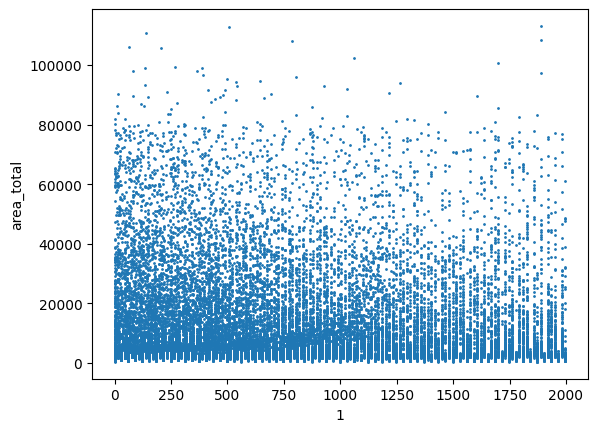

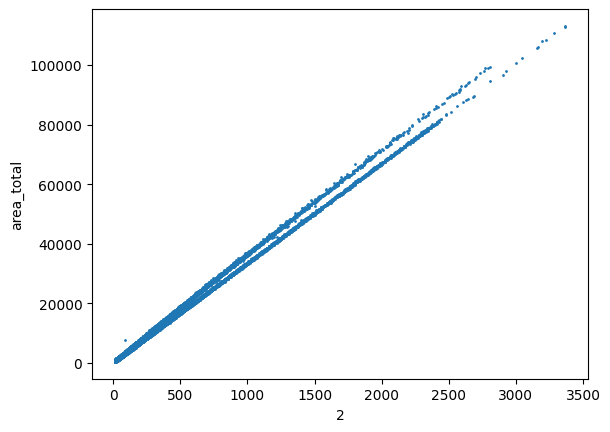

In [ ]:
plt.scatter(dataset.iloc[:,1], dataset["area_total"], s=1)
plt.xlabel("1")
plt.ylabel("area_total")
plt.show()

plt.scatter(dataset.iloc[:,2], dataset["area_total"], s=1)
plt.xlabel("2")
plt.ylabel("area_total")
plt.show()

Первый сигнал никак не коррелирует с площадью, на диаграмме хаос. А вот вторая диаграмма весьма любопытная. Похоже, параметр 2 - вычисленная электроникой ФЭУ часть или другая линейная функция площади пика. Более того, на диаграмме четко видно 2 линейных кластера точек. Используем это для поиска сильного разделяющего признака.

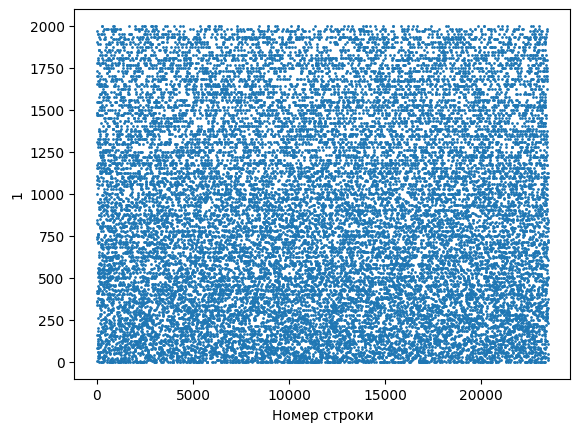

In [276]:
plt.scatter(
    dataset.index,
    dataset.iloc[:,1],
    s=1
)
plt.xlabel("Номер строки")
plt.ylabel("1")
plt.show()

Параметр 1 распределен практически равномерно по номерам строк. Не видно связи с временем регистрации или номером строки.

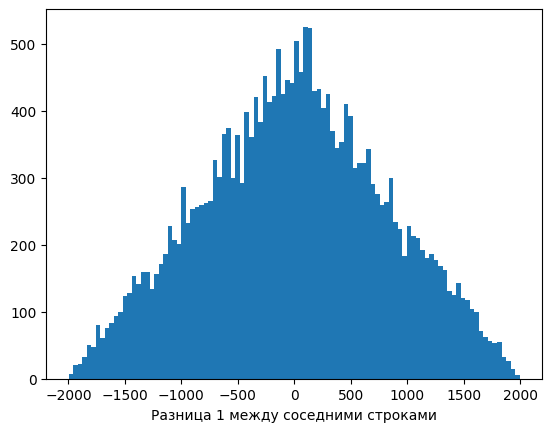

-1998 1993


In [ ]:
diff = np.diff(dataset.iloc[:,1])

plt.hist(diff, bins=100)
plt.xlabel("Разница 1 между соседними строками")
plt.show()

print(diff.min(), diff.max())

Распределение разницы соседних строк треугольное. Похоже, соседние значения никак не коррелируют.

In [ ]:
signal = dataset.iloc[:, 3:503]

# Положение пика, мс
dataset["peak_pos"] = signal.to_numpy().argmin(axis=1)

In [ ]:
dataset.head()

,0,1,2,4,5,6,7,8,9,10,...,498,499,500,501,502,503,baseline,peak,area_total,peak_pos
0,2890276,357,113,14820,14823,14824,14822,14818,14820,14824,...,14817,14819,14820,14822,14820,14819,14821.13,530.13,4614.0,149
1,4928764,740,359,14820,14822,14820,14826,14824,14822,14820,...,14824,14819,14820,14819,14822,14820,14822.47,1901.47,12348.0,150
2,9630204,162,499,14820,14820,14822,14825,14820,14824,14824,...,14818,14821,14823,14820,14820,14821,14821.92,2557.92,16955.0,151
3,15798632,841,123,14828,14822,14818,14824,14824,14822,14820,...,14820,14828,14820,14822,14823,14822,14822.76,564.76,4658.0,149
4,20637296,412,348,14823,14815,14823,14821,14827,14820,14823,...,14824,14820,14824,14824,14822,14825,14821.43,1793.43,11606.0,150


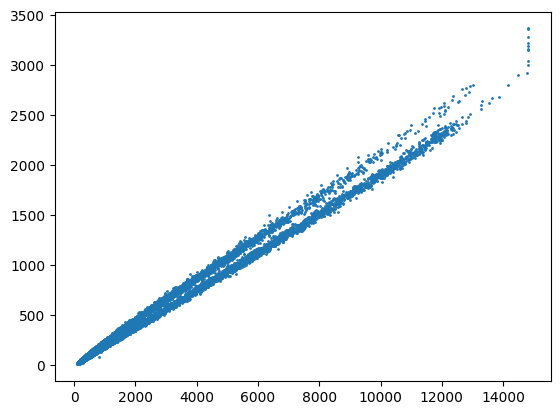

In [ ]:
plt.scatter(dataset["peak"],
            dataset.iloc[:,2],
            s=1)

Параметр 2 также коррелирует с максимумом пика. Максимум связан с площадью, так что это ожидаемо.

Удалось найти хороший параметр - форма пика. Она получается как отношение рассчитанной по вектору сигнала площади к максимуму. На гистограмме видно 2 четких максимума, что поможет при разделении сигналов на кластеры.

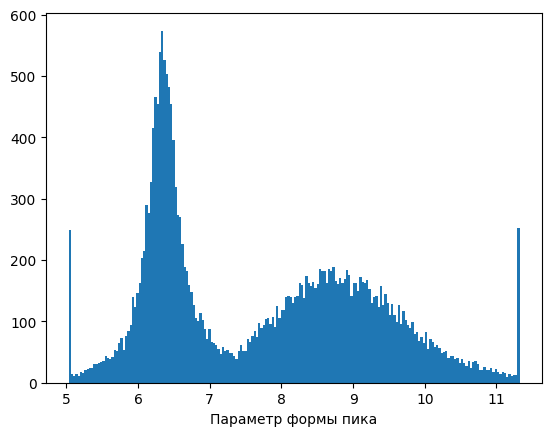

In [277]:
dataset["shape"] = dataset["area_total"] / dataset["peak"]

dataset["shape"] = dataset["shape"].clip(
    lower=dataset["shape"].quantile(0.01),
    upper=dataset["shape"].quantile(0.99)
)

plt.hist(dataset["shape"], bins=200)
plt.xlabel("Параметр формы пика")
plt.show()

Также рассчитаем форму по параметру 2, который ведет себя как некая площадь части сигнала

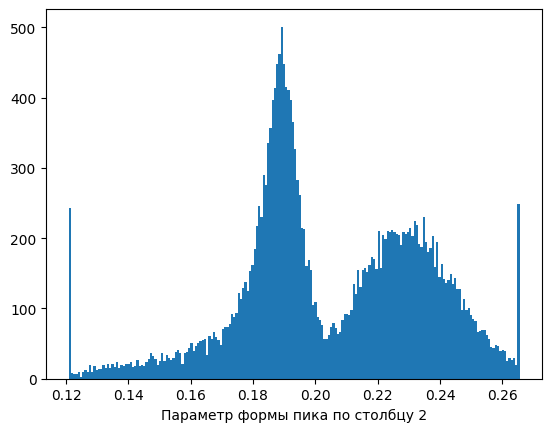

In [279]:
dataset["shape_source"] = dataset.iloc[:, 2] / dataset["peak"]

dataset["shape_source"] = dataset["shape_source"].clip(
    lower=dataset["shape_source"].quantile(0.01),
    upper=dataset["shape_source"].quantile(0.99)
)

plt.hist(dataset["shape_source"], bins=200)
plt.xlabel("Параметр формы пика по столбцу 2")
plt.show()

Сами площади и пик (точнее их логарифмы) не имеют выраженных мод на распределении

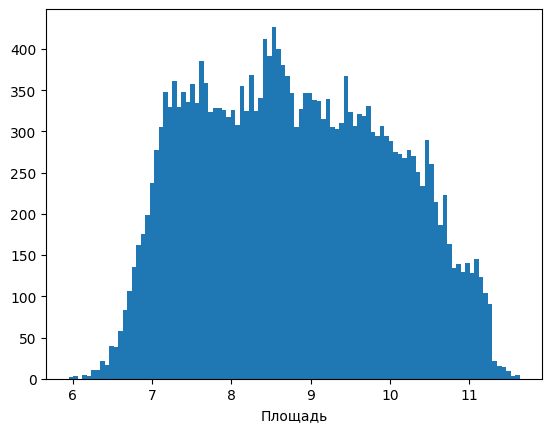

In [ ]:
plt.hist(np.log1p(dataset["area_total"]), bins=100)
plt.xlabel("Площадь")
plt.show()

In [283]:
dataset["area_log"] = np.log1p(dataset["area_total"])

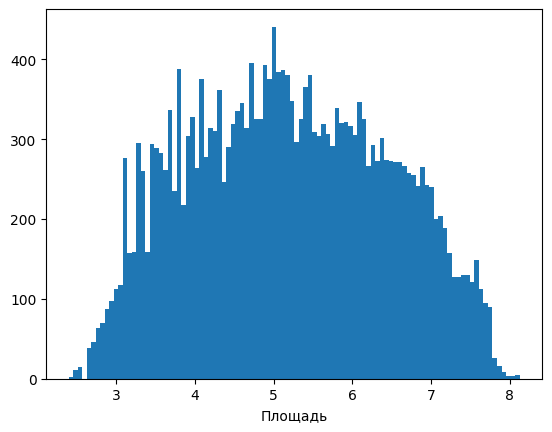

In [ ]:
plt.hist(np.log1p(dataset.iloc[:, 2]), bins=100)
plt.xlabel("Площадь")
plt.show()

In [285]:
dataset["area2_log"] = np.log1p(dataset.iloc[:, 2])

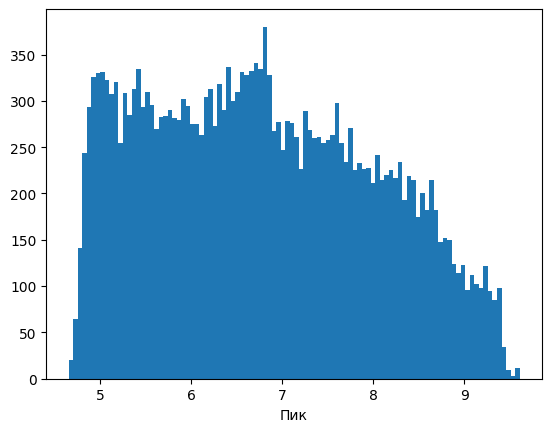

In [ ]:
plt.hist(np.log1p(dataset["peak"]), bins=100)
plt.xlabel("Пик")
plt.show()

In [286]:
dataset["peak_log"] = np.log1p(dataset["peak"])

Расчет отношения вычисленной и данной площади

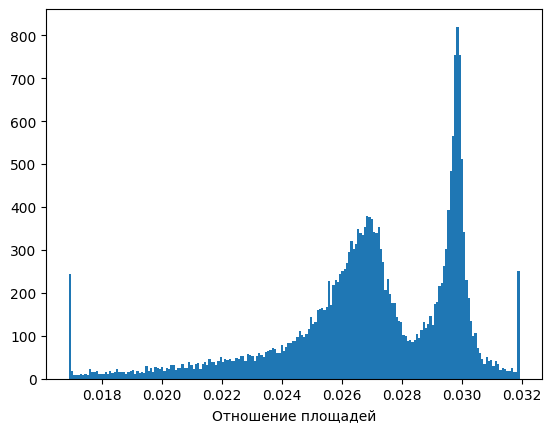

In [280]:
dataset["area_ratio"] = dataset.iloc[:, 2] / dataset['area_total']

dataset["area_ratio"] = dataset["area_ratio"].clip(
    lower=dataset["area_ratio"].quantile(0.01),
    upper=dataset["area_ratio"].quantile(0.99)
)

plt.hist(dataset["area_ratio"], bins=200)
plt.xlabel("Отношение площадей")
plt.show()

In [ ]:
# Колонки с вектором сигнала
sig_cols = dataset.columns[SIG_START:SIG_END]

In [ ]:
def signal_tail(row, high=0.4, low=0.1):
    """
    Поиск отсчетов хвоста сигнала по уровню от пика - от low до high
    """
    x = np.asarray(row, dtype=float)

    p = np.argmax(x)
    peak = x[p]

    if peak <= 0:
        return np.array([]), peak

    after = x[p:]

    start_candidates = np.where(after < peak * high)[0]
    end_candidates = np.where(after < peak * low)[0]

    if len(start_candidates) == 0 or len(end_candidates) == 0:
        return np.array([]), peak

    start = p + start_candidates[0]
    end = p + end_candidates[0]

    if end <= start:
        return np.array([]), peak

    return x[start:end], peak

In [ ]:
# Аппроксимация хвоста пика экспонентой
def exp_cut(t, A, tau):
    return A * np.exp(-t / tau)

def estimate_tau(row, high=0.4, low=0.1, func=exp_cut):
    """
    Подбор постоянной времени tau путем аппроксимации хвоста пика экспонентой
    """
    tail, peak = signal_tail(
        row,
        high=high,
        low=low
    )

    t = np.arange(len(tail), dtype=float)
    y = tail.astype(float)

    # начальные оценки
    A0 = y[0]
    tau0 = max(len(y) / 3, 0.1)

    if A0 <= 0:
        return np.nan

    try:
        popt, pcov = curve_fit(
            func,
            t,
            y,
            p0=[A0, tau0],
            bounds=(
                [0, 1e-4],
                [peak, 100]
            ),
            maxfev=5000
        )

        A, tau = popt

        if tau <= 0:
            return np.nan

        return tau

    except Exception as e:
        return np.nan

In [27]:
signals = (dataset["baseline"].values[:, None] - dataset[signal_cols]).to_numpy()
dataset["tau_cut"] = [np.log1p(estimate_tau(sig, high=0.4, low=0.01, func=exp_cut)) for sig in signals]

Попытка рассчитать отдельно площади до максимума пика и после

In [ ]:
peak_pos = dataset["peak_pos"].to_numpy()

area_before = np.zeros(len(signals))
area_after = np.zeros(len(signals))

for i in range(len(signals)):
    p = peak_pos[i]
    area_before[i] = signals[i, :p].sum()
    area_after[i] = signals[i, p:].sum()

dataset["area_before_peak"] = area_before
dataset["area_after_peak"] = area_after

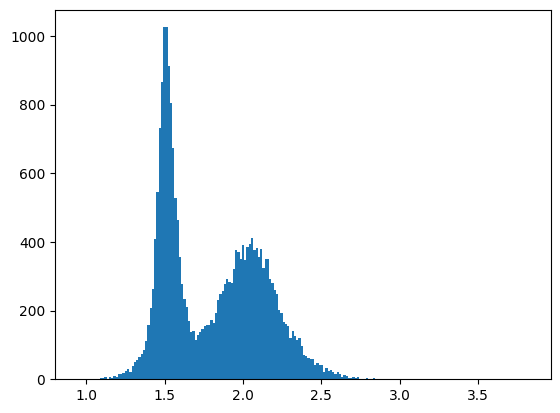

In [29]:
plt.hist(dataset["tau_cut"], bins=200)
plt.show()

Получилась наглядная оценка tau - два явных максимума на распределении. В то же время это очень похоже на shape, что считали выше

Отношение площадей до максимума и после. Распределение не имеет выраженных двух максимумов

In [63]:
dataset["peak_ratio"] = dataset["area_after_peak"] / dataset["area_before_peak"]

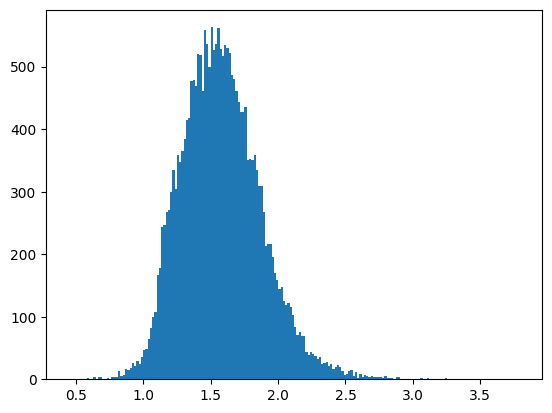

In [64]:
plt.hist(np.log1p(dataset["peak_ratio"]), bins=200)
plt.show()

In [288]:
dataset["peak_ratio_log"] = np.log1p(dataset["peak_ratio"])

In [119]:
def width_at_fraction(signal, frac=0.5, sig_front=False):

    """
    Функция расчета ширины пика или длины хвоста по заданному уровню.
    Используется интерполяция значений
    """

    x = np.asarray(signal, dtype=float)

    peak_idx = np.argmax(x)
    peak = x[peak_idx]

    if peak <= 0:
        return np.nan

    level = frac * peak

    if sig_front:
        left = np.where(x[:peak_idx] < level)[0]

        if len(left) == 0:
            return np.nan

        i = left[-1]

        y0 = x[i]
        y1 = x[i + 1]

        left_cross = i + (level - y0) / (y1 - y0)
    else:
        left_cross = peak_idx

    right = np.where(x[peak_idx:] < level)[0]

    if len(right) == 0:
        return np.nan

    j = peak_idx + right[0]

    y0 = x[j - 1]
    y1 = x[j]

    right_cross = (j - 1) + (level - y0) / (y1 - y0)

    return right_cross - left_cross

In [120]:
dataset["width50"] = [width_at_fraction(sig, 0.5) for sig in signals]
dataset["width30"] = [width_at_fraction(sig, 0.3) for sig in signals]
dataset["width10"] = [width_at_fraction(sig, 0.1) for sig in signals]

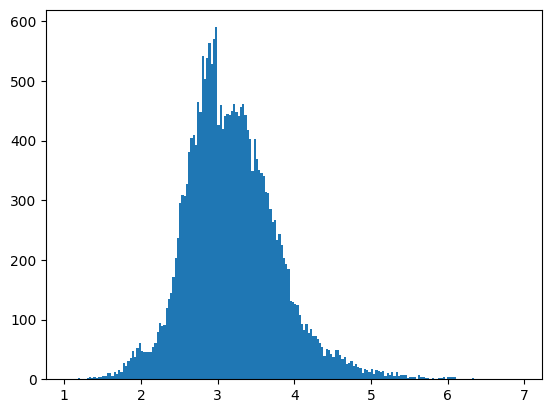

In [123]:
plt.hist(dataset["width50"], bins=200)
plt.show()

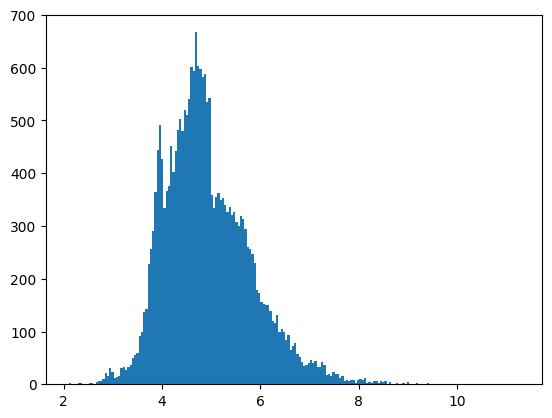

In [124]:
plt.hist(dataset["width30"], bins=200)
plt.show()

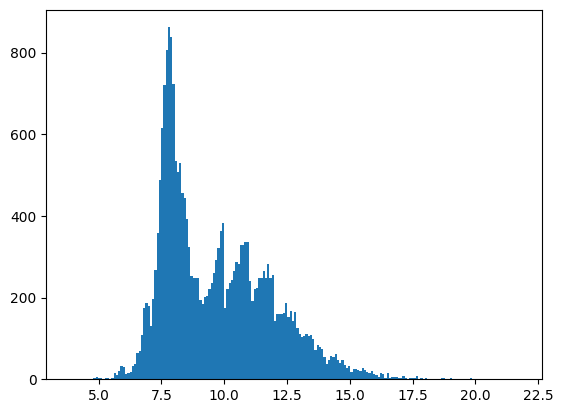

In [125]:
plt.hist(dataset["width10"], bins=200)
plt.show()

In [126]:
dataset["width07"] = [width_at_fraction(sig, 0.07) for sig in signals]

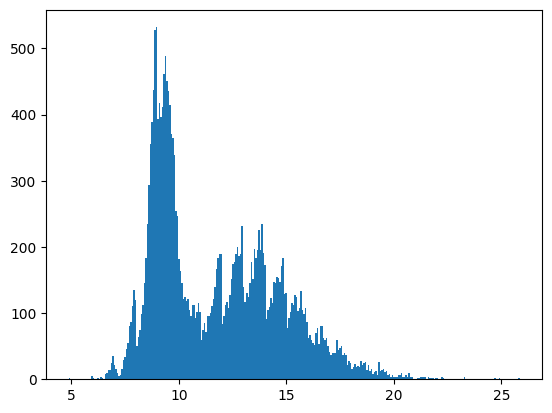

In [127]:
plt.hist(dataset["width07"], bins=300)
plt.show()

In [128]:
dataset["width05"] = [width_at_fraction(sig, 0.05) for sig in signals]

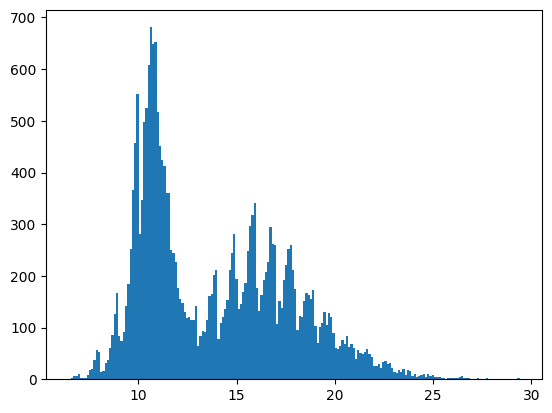

In [129]:
plt.hist(dataset["width05"], bins=200)
plt.show()

In [137]:
dataset["width03"] = [width_at_fraction(sig, 0.03) for sig in signals]

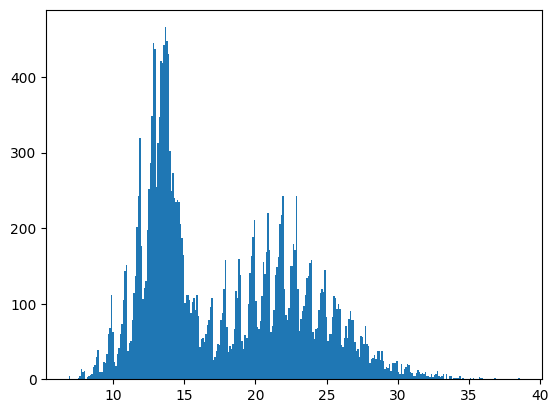

In [138]:
plt.hist(dataset["width03"], bins=300)
plt.show()

In [130]:
dataset["width02"] = [width_at_fraction(sig, 0.02) for sig in signals]

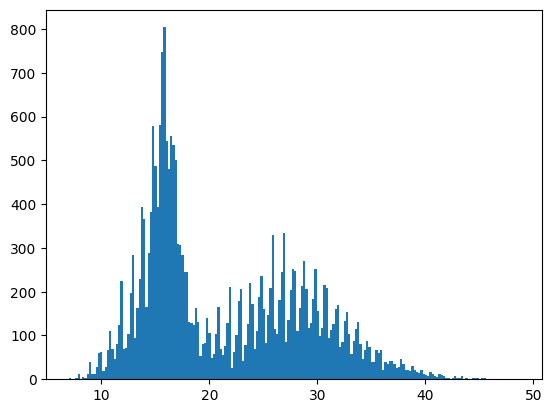

In [134]:
plt.hist(dataset["width02"], bins=200)
plt.show()

С уменьшением высоты определения длины хвоста все четче наблюдаются 2 максимума на гистограмме. Для 10, 30 и 50% двух максимумов не видно, но наиболее интересны уровни 2, 3 и 5%. Зазубрины связаны с тем, что значения интерполируются

In [142]:
dataset.iloc[:,504:].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   peak              23479 non-null  float64
 1   area_total        23479 non-null  float64
 2   peak_pos          23479 non-null  int64  
 3   shape             23479 non-null  float64
 4   shape_source      23479 non-null  float64
 5   area_ratio        23479 non-null  float64
 6   tau_cut           23479 non-null  float64
 7   tau_front         23479 non-null  float64
 8   tail              23479 non-null  int64  
 9   cluster           23479 non-null  float64
 10  area_before_peak  23479 non-null  float64
 11  area_after_peak   23479 non-null  float64
 12  peak_ratio        23479 non-null  float64
 13  area_after_ratio  23479 non-null  float64
 14  width50           23479 non-null  float64
 15  width30           23479 non-null  float64
 16  width10           23479 non-null  float6

In [143]:
dataset.iloc[:,504:].head(20)

,peak,area_total,peak_pos,shape,shape_source,area_ratio,tau_cut,tau_front,tail,cluster,...,area_after_peak,peak_ratio,area_after_ratio,width50,width30,width10,width05,width02,width03,width07
0,530.13,4614.0,149,8.703526,0.213155,0.024491,1.881892,4.615121,44,1.0,...,3815.63,4.779275,0.826968,3.320867,5.629235,10.757312,14.374786,23.826370,23.561305,12.456445
1,1901.47,12348.0,150,6.493923,0.188801,0.029074,1.486120,4.615121,17,0.0,...,10118.50,4.538462,0.819444,3.393865,4.903359,8.232509,10.761014,16.029373,14.907406,9.606189
2,2557.92,16955.0,151,6.628432,0.195080,0.029431,1.597135,4.615121,16,-1.0,...,11324.08,2.011053,0.667890,2.503356,3.861644,7.354447,12.000923,15.963576,15.211247,9.221821
3,564.76,4658.0,149,8.247751,0.217792,0.026406,1.928359,4.615121,28,1.0,...,3993.76,6.012526,0.857398,3.646105,5.541625,9.364889,11.816947,32.146480,18.727221,11.222463
4,1793.43,11606.0,150,6.471398,0.194042,0.029984,1.532409,4.615121,21,0.0,...,9045.50,3.532708,0.779381,3.173829,4.627697,8.894243,10.564529,18.597588,14.209033,9.755908
5,235.35,2394.0,150,10.172084,0.259188,0.025480,2.131278,4.615121,26,1.0,...,1661.50,2.268259,0.694027,3.067000,5.528654,12.302500,13.947813,29.660750,20.644750,13.359438
6,844.65,7561.0,150,8.951637,0.230865,0.025790,2.281904,4.615121,46,1.0,...,6297.50,4.984171,0.832892,3.538128,5.177384,9.850897,17.631071,30.717133,27.044357,14.754083
7,167.47,1060.0,148,6.329492,0.185108,0.029245,1.989396,4.615121,24,0.0,...,821.44,3.443327,0.774943,2.568375,5.009957,11.344600,12.849417,18.780150,15.611475,12.291183
8,2062.91,13481.0,151,6.534943,0.192447,0.029449,1.565245,4.615121,19,0.0,...,9413.59,2.314394,0.698286,2.640399,3.932811,7.640292,10.621843,15.720983,12.903958,8.785843
9,1639.95,14449.0,151,8.810634,0.238422,0.027061,2.083477,4.615121,38,1.0,...,11518.55,3.930642,0.797187,3.365529,5.423432,12.490763,16.789688,26.832652,22.194611,13.832761


In [113]:
def save_clusters_csv(labels, filename="clusters.csv"):
    labels = np.asarray(labels)
    """
    Сохранение результатов кластеризации в файл csv согласно
    требованиям на Kaggle
    """
    # уникальные кластеры по возрастанию
    unique_clusters = np.sort(np.unique(labels))

    # отображение старый -> новый
    cluster_map = {
        old: new
        for new, old in enumerate(unique_clusters)
    }

    # перенумерация
    new_labels = np.vectorize(cluster_map.get)(labels)

    result = pd.DataFrame({
        "index": np.arange(len(labels)),
        "cluster": new_labels
    })

    result.to_csv(filename, index=False)

    return result, cluster_map

In [306]:
# Используемые признаки
features = [
    "shape",
    "shape_source",
    "area_ratio",
    "tau_cut",
    "width02",
    "width03",
    "width05",
    "area2_log",
    "peak_log",
    "peak_ratio_log"
]

X = dataset[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

<Axes: >

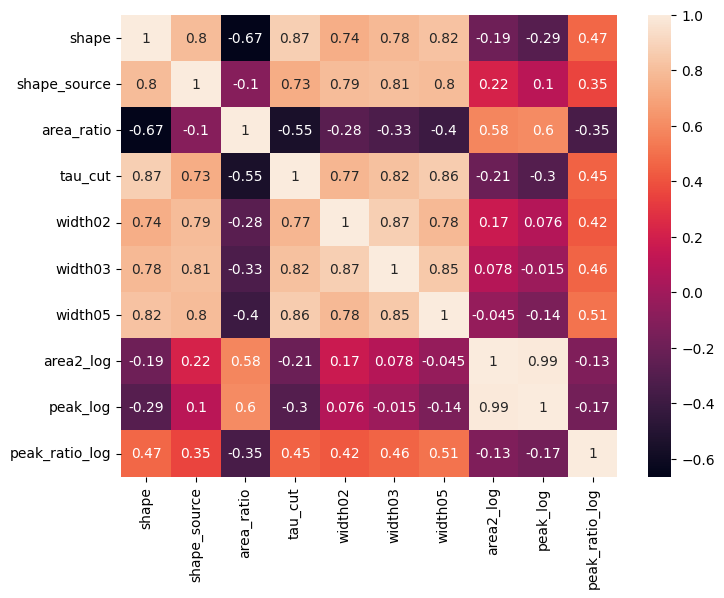

In [290]:
corr = dataset[features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)

In [291]:
pca = PCA()
pca.fit(X_scaled)

print(np.cumsum(pca.explained_variance_ratio_))

[0.55846795 0.81390171 0.88545203 0.93238281 0.95837212 0.9766586
 0.9885502  0.99898994 0.99998787 1.        ]


Видно, что между признаками есть корреляции, но доля объясненной дисперсии растет не настолько быстро, чтобы существенно сократить размерность

Кластеризация Gaussian Mixture в предположении, что множество для кластеризации может быть представлено как совокупность гауссовых плотностей точек. Метод требует задания количества кластеров, не выделяет шум автоматически. Шум определяется по порогу уверенности отнесения точки к кластеру. Если уверенность менее 95%, точка считается шумом

In [292]:
gmm = GaussianMixture(
    n_components=2,
    covariance_type="full",
    random_state=42
)

gmm.fit(X_scaled)
proba = gmm.predict_proba(X_scaled)
confidence = proba.max(axis=1)
labels = gmm.predict(X_scaled)

threshold = 0.95
labels_with_noise = labels.copy()

labels_with_noise[confidence < threshold] = 2

dataset.loc[X.index, "cluster"] = labels_with_noise

In [293]:
pd.Series(labels_with_noise).value_counts()

,count
1,12524
0,10497
2,458


Рассчитаны метрики. Индекс Калински-Харабаша не нормирован и позволяет только сравнивать разные методы между собой. Коэффициент силуэта при идеальной кластеризации будет равен 1. Меньше - хуже

In [294]:
silh = silhouette_score(X, labels_with_noise)
calin = calinski_harabasz_score(X, labels_with_noise)

print("CH =", calin)
print("Silhouette =", silh)

CH = 23554.145611228134
Silhouette = 0.34205026386290255


In [295]:
result, mapping = save_clusters_csv(
    dataset["cluster"],
    "gmm.csv"
)

In [296]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=1000,
    min_samples=20
)

labels = clusterer.fit_predict(X_scaled)
# Перенумерация кластера с шумом
labels[labels == -1] = 2
dataset.loc[X.index, "cluster"] = labels
pd.Series(labels).value_counts()

,count
1,10300
0,8203
2,4976


Перебор некоторых параметров HDBSCAN для поиска наилучшей по метрикам комбинации с 2 кластерами + шум

In [297]:
results = []

for min_cluster_size in [50, 100, 200, 300, 500, 800, 1000]:
    for min_samples in [5, 10, 20, 30, 50, 100]:
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            metric="euclidean"
        )

        labels = clusterer.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_share = np.mean(labels == -1)

        # метрики только если есть хотя бы 2 не-шумовых кластера
        mask = labels != -1

        if n_clusters >= 2 and mask.sum() > 0:
            sil = silhouette_score(X_scaled[mask], labels[mask])
            ch = calinski_harabasz_score(X_scaled[mask], labels[mask])
        else:
            sil = np.nan
            ch = np.nan

        results.append({
            "min_cluster_size": min_cluster_size,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "noise_share": noise_share,
            "silhouette": sil,
            "calinski_harabasz": ch,
        })

results_df = pd.DataFrame(results)

results_df.sort_values(
    ["n_clusters", "silhouette", "calinski_harabasz"],
    ascending=[True, False, False]
)

,min_cluster_size,min_samples,n_clusters,noise_share,silhouette,calinski_harabasz
5,50,100,2,0.383747,0.546189,23526.485800
11,100,100,2,0.383747,0.546189,23526.485800
17,200,100,2,0.383747,0.546189,23526.485800
23,300,100,2,0.383747,0.546189,23526.485800
29,500,100,2,0.383747,0.546189,23526.485800
35,800,100,2,0.383747,0.546189,23526.485800
41,1000,100,2,0.383747,0.546189,23526.485800
4,50,50,2,0.316751,0.532428,24470.495795
10,100,50,2,0.316751,0.532428,24470.495795
16,200,50,2,0.316751,0.532428,24470.495795


In [298]:
best = (
    results_df
    .query("n_clusters == 2")
    .sort_values(
        ["silhouette", "calinski_harabasz"],
        ascending=[False, False]
    )
)

best.head(20)

,min_cluster_size,min_samples,n_clusters,noise_share,silhouette,calinski_harabasz
5,50,100,2,0.383747,0.546189,23526.485800
11,100,100,2,0.383747,0.546189,23526.485800
17,200,100,2,0.383747,0.546189,23526.485800
23,300,100,2,0.383747,0.546189,23526.485800
29,500,100,2,0.383747,0.546189,23526.485800
35,800,100,2,0.383747,0.546189,23526.485800
41,1000,100,2,0.383747,0.546189,23526.485800
4,50,50,2,0.316751,0.532428,24470.495795
10,100,50,2,0.316751,0.532428,24470.495795
16,200,50,2,0.316751,0.532428,24470.495795


Вызов кластеризации с наилучшими параметрами

In [299]:
best_params = best.iloc[0]

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=int(best_params["min_cluster_size"]),
    min_samples=int(best_params["min_samples"]),
    metric="euclidean"
)

labels = clusterer.fit_predict(X_scaled)
labels_with_noise = labels.copy()
labels_with_noise[labels_with_noise == -1] = 2

dataset.loc[X.index, "cluster"] = labels_with_noise

По метрикам и по результату на Kaggle метод хуже

In [300]:
silh = silhouette_score(X_scaled, labels)
calin = calinski_harabasz_score(X_scaled, labels)

print("CH =", calin)
print("Silhouette =", silh)

CH = 8742.404078670424
Silhouette = 0.2567187031119485


In [301]:
result, mapping = save_clusters_csv(
    dataset["cluster"],
    "hdbscan.csv"
)

Результат на Kaggle около 0,77

In [318]:
# С этими признаками KMeans выдает наилучший результат
features = [
    "shape",
    "shape_source",
    "area_total",
    "tau_cut",
    "width02",
    "width03",
    "width05"
]

X = dataset[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

KMeans также требует указания количества кластеров и не определяет шум, поэтому шумовые точки определялись как лежащие за пределами 99 процентиля расстояния от центроидов. Но честно говоря, без третьего класса метрика accuracy даже чуть выше. Попытки выделить шум только снижают точность.

In [322]:
clusterer = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

labels = clusterer.fit_predict(X_scaled)
centers = clusterer.cluster_centers_

dist = np.linalg.norm(X_scaled - centers[labels], axis=1)
threshold = np.percentile(dist, 99)
labels_with_noise = labels.copy()

labels_with_noise[dist > threshold] = 2

dataset.loc[X.index, "cluster"] = labels_with_noise
pd.Series(labels_with_noise).value_counts()

,count
1,11943
0,11301
2,235


Лучший результат дал KMeans - около 0,842. Остальные метрики тоже лучше остальных методов. Но нужно убрать некоторые признаки. Не использовались логарифмированные признаки.

In [316]:
silh = silhouette_score(X_scaled, labels)
calin = calinski_harabasz_score(X_scaled, labels)

print("CH =", calin)
print("Silhouette =", silh)

CH = 36719.71717283182
Silhouette = 0.5308157346934796


In [323]:
result, mapping = save_clusters_csv(
    dataset["cluster"],
    "kmeans.csv"
)

Наилучший результат показал KMeans. Это связано с формой и структурой кластеров, которые, видимо, близки к сферическим и не образуют плотных скоплений. Поэтому HDBSCAN не дает высокого результата даже после подбора параметров. Gaussian Mixture тоже достойно справился, но отстает от KMeans

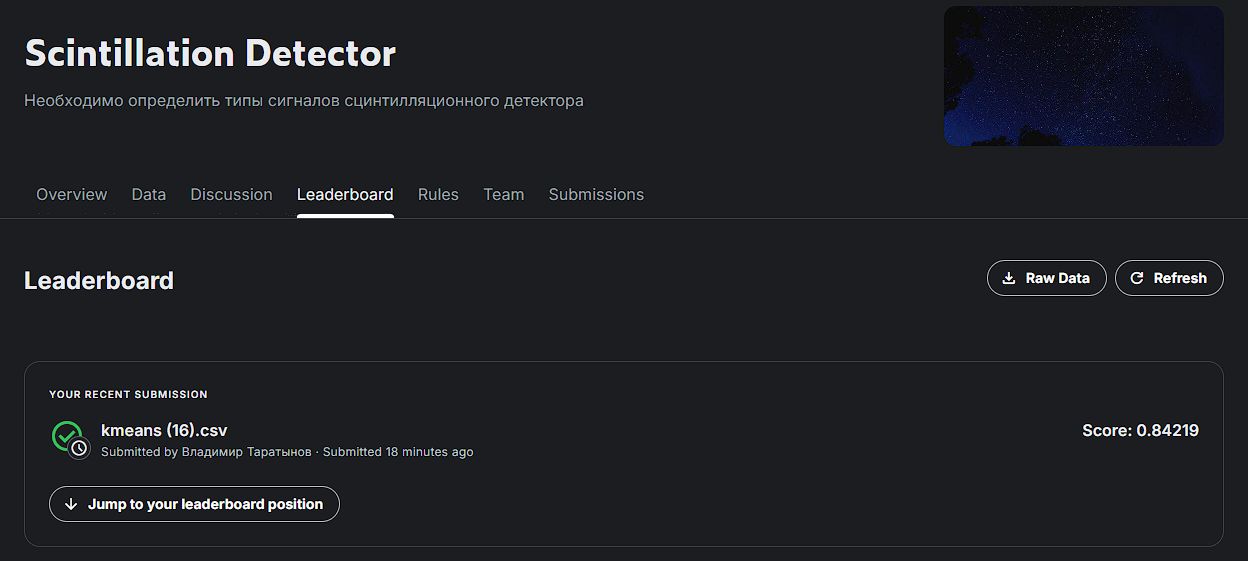